# SoRelle et al Data Visualization using Scanpy

reference code: https://github.com/quadbio/scRNAseq_analysis_python_vignette/blob/main/Tutorial.ipynb and scanpy tutorial

## Import, QC, and Visualize scRNAseq data

In [2]:
import cobra
import matplotlib.pyplot as plt
import GEOparse
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
from scipy import stats
from utils.cfr_suite import apply_cfr 

### Initital dataset loading and QC

In [2]:
# gse = GEOparse.get_GEO(geo="GSE189141", destdir="./data")

# for k, v in gse.gsms.items():
#     print(k, v.metadata)

In [3]:
# for gsm in tqdm(gse.gsms.values()):
#     url = gsm.metadata[f'supplementary_file_1'][0]
#     if f'GEX'in url:
#         gsm.download_supplementary_files(directory='./data')

In [ ]:
adatas = {}

times = ["0", "2", "5", "8"]

samples = [
    "GSM5695144_TX1241_0_GEX_EBV_", 
    "GSM5695146_TX1241_2_GEX_EBV_", 
    "GSM5695148_TX1241_5_GEX_EBV_", 
    "GSM5695150_TX1241_8_GEX_EBV_"
]

for t, s in zip(times, samples):   

    sample_id = f"TX1241_{t}"
    sample_adata = sc.read_10x_mtx(f"./data/TX1241_{t}_GEX",
                                   prefix=s,
                                   var_names="gene_symbols",
                                   )

    print(f"Loaded state: {sample_id}")
    print(sample_adata)

    sample_adata.obs_names_make_unique()
    sample_adata.var_names_make_unique()


    sample_adata.var["mt"] = sample_adata.var_names.str.startswith("MT-")

    sc.pp.calculate_qc_metrics(sample_adata, qc_vars=["mt"], inplace=True)

    sample_adata = sample_adata[(sample_adata.obs["pct_counts_mt"] < 20) &
                                (sample_adata.obs["total_counts"] < 25000) &
                                (sample_adata.obs["n_genes_by_counts"] > 1000)
                                ].copy()
    
    print(f"After QC: {sample_id}")
    print(sample_adata)

    sc.pp.filter_genes(sample_adata, min_cells=3)

    print(f"After gene filtering: {sample_id}")
    print(sample_adata)

    adatas[sample_id] = sample_adata

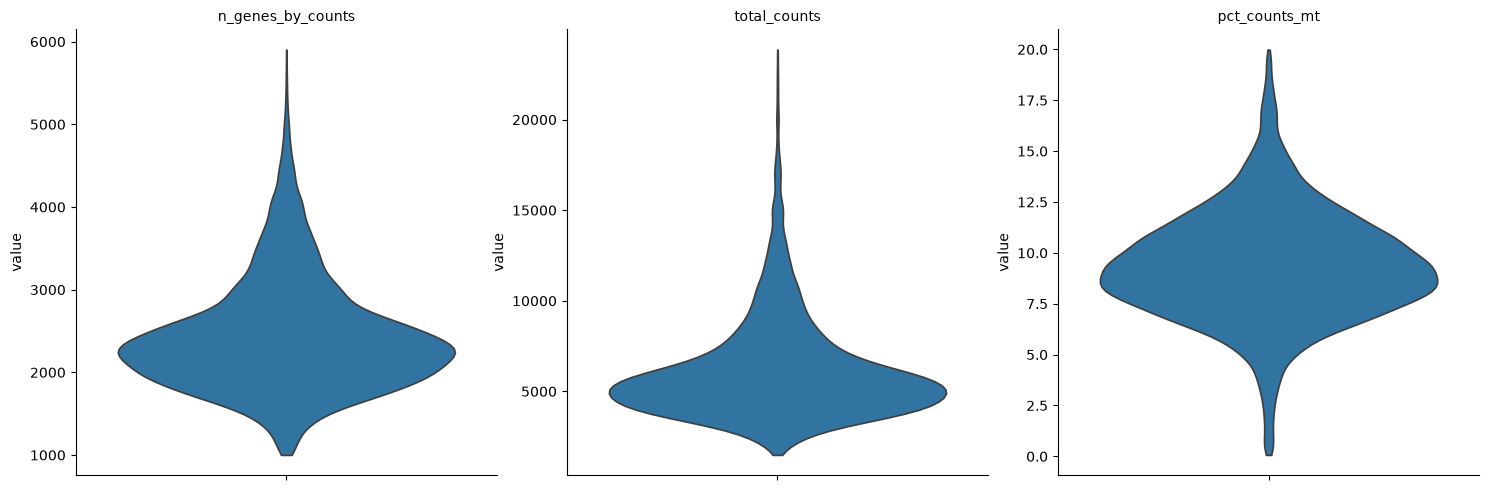

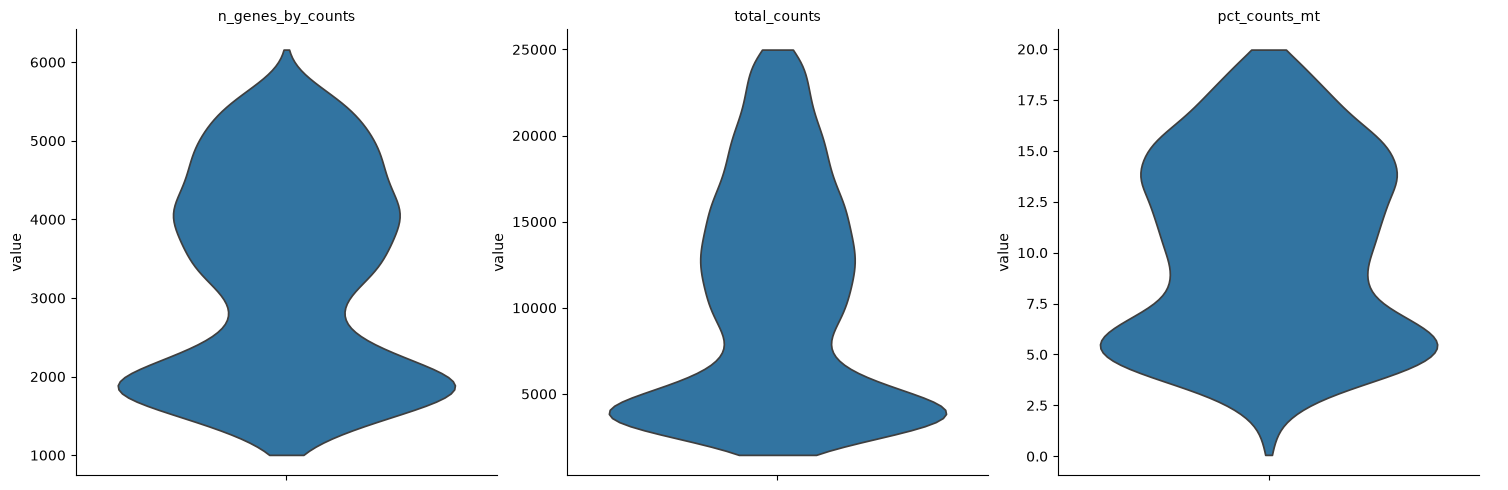

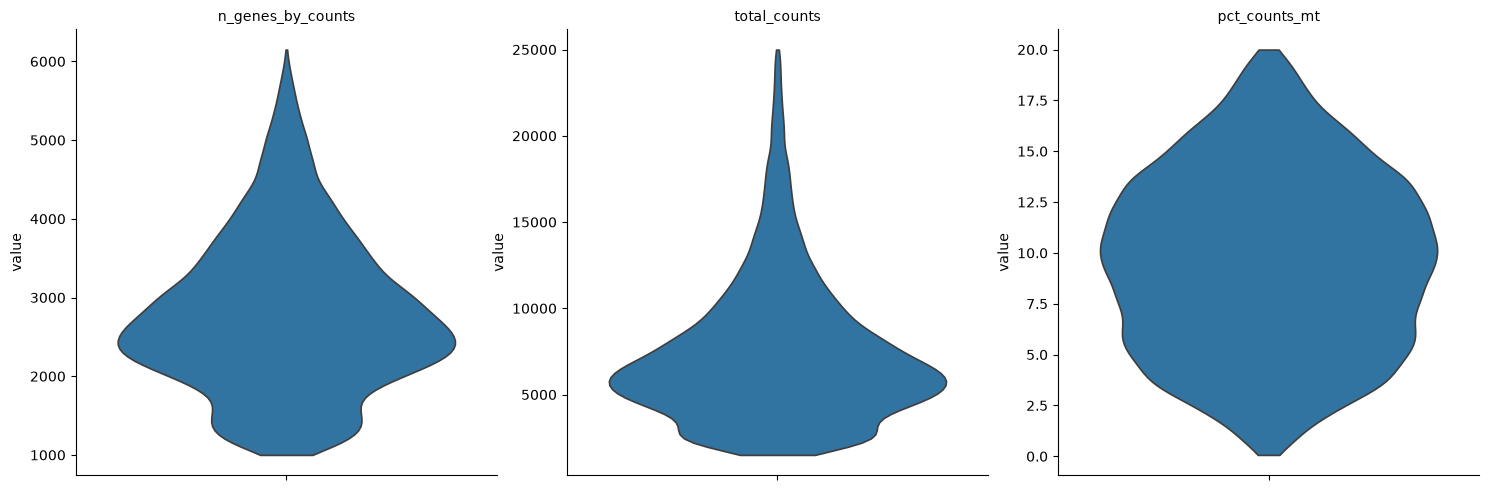

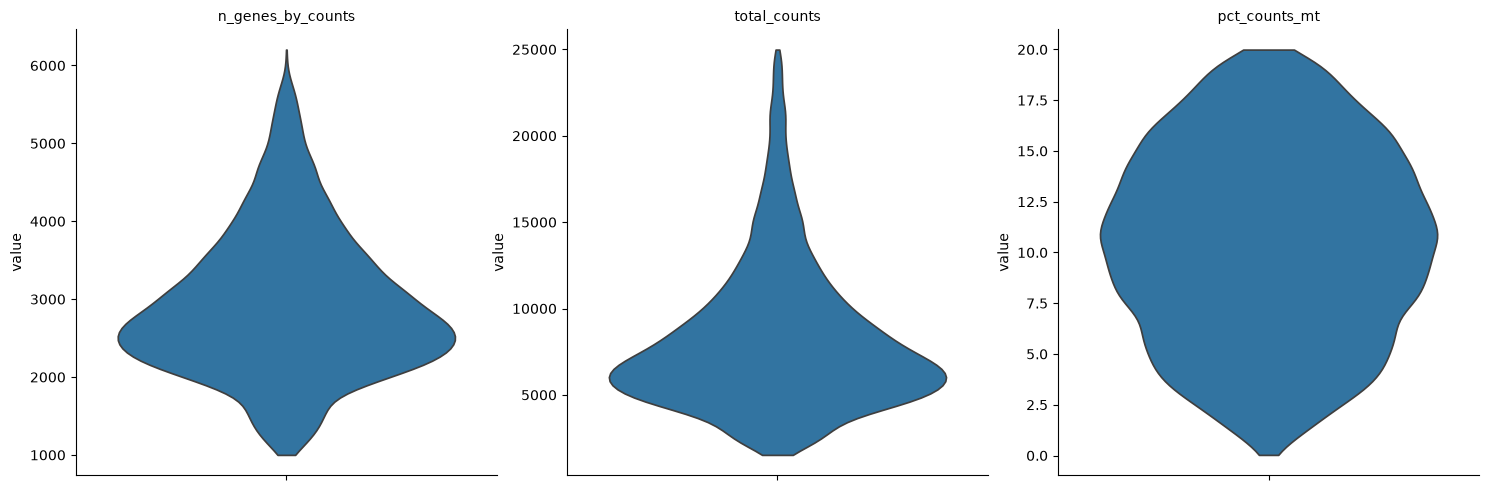

In [ ]:
for t in times: 
    label = f'TX1241_{t}'
    sc.pl.violin(adatas[label], ["n_genes_by_counts", "total_counts", "pct_counts_mt"], size=0, multi_panel=True)

In [ ]:
adata = ad.concat(adatas, label="timepoint", join="outer", index_unique="-")

sc.pp.scrublet(adata, batch_key="timepoint")
# adata.obs_names_make_unique()

print("\nCells after combining samples:")
print(adata.obs["timepoint"].value_counts())

print("\nFinal AnnData:")
print(adata)


Cells after combining samples:
timepoint
TX1241_5    18831
TX1241_8    14715
TX1241_2     8848
TX1241_0     8405
Name: count, dtype: int64

Final AnnData:
AnnData object with n_obs × n_vars = 50799 × 26449
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'timepoint', 'n_genes', 'doublet_score', 'predicted_doublet'
    uns: 'scrublet'
    layers: None (.X)


In [38]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata)

adata.X.data = np.log2(adata.X.data + 1)
adata.layers["log2"] = adata.X.copy()

adata.X = sc.pp.log1p(adata.layers["counts"])

### load from here after initial run

In [3]:
# adata.write_h5ad("./data/processed_TX1241.h5ad")
adata = sc.read_h5ad("./data/processed_TX1241.h5ad")

Here I could regress out cell cycle but do not currently

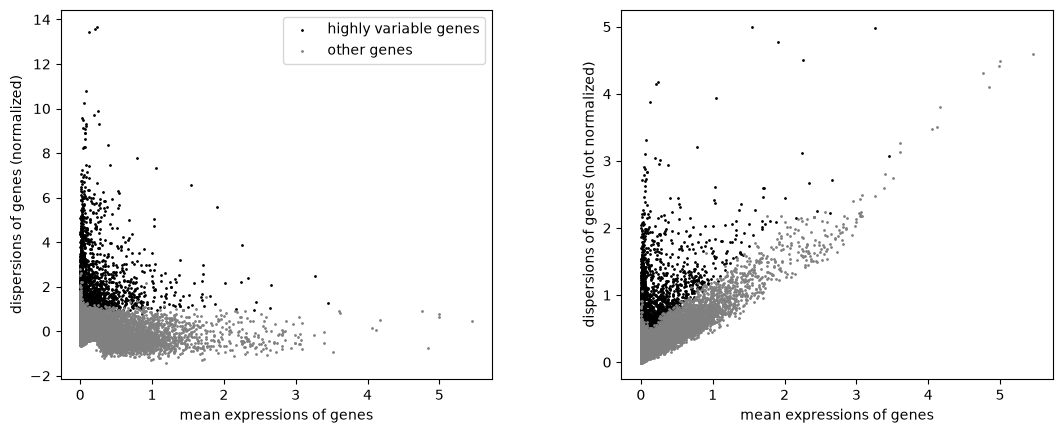

In [4]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="timepoint")
sc.pl.highly_variable_genes(adata)

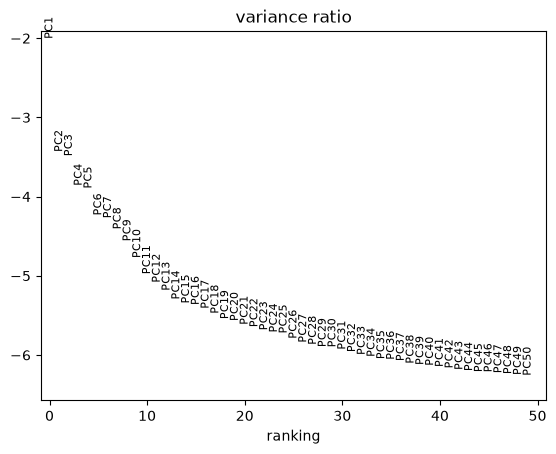

In [5]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

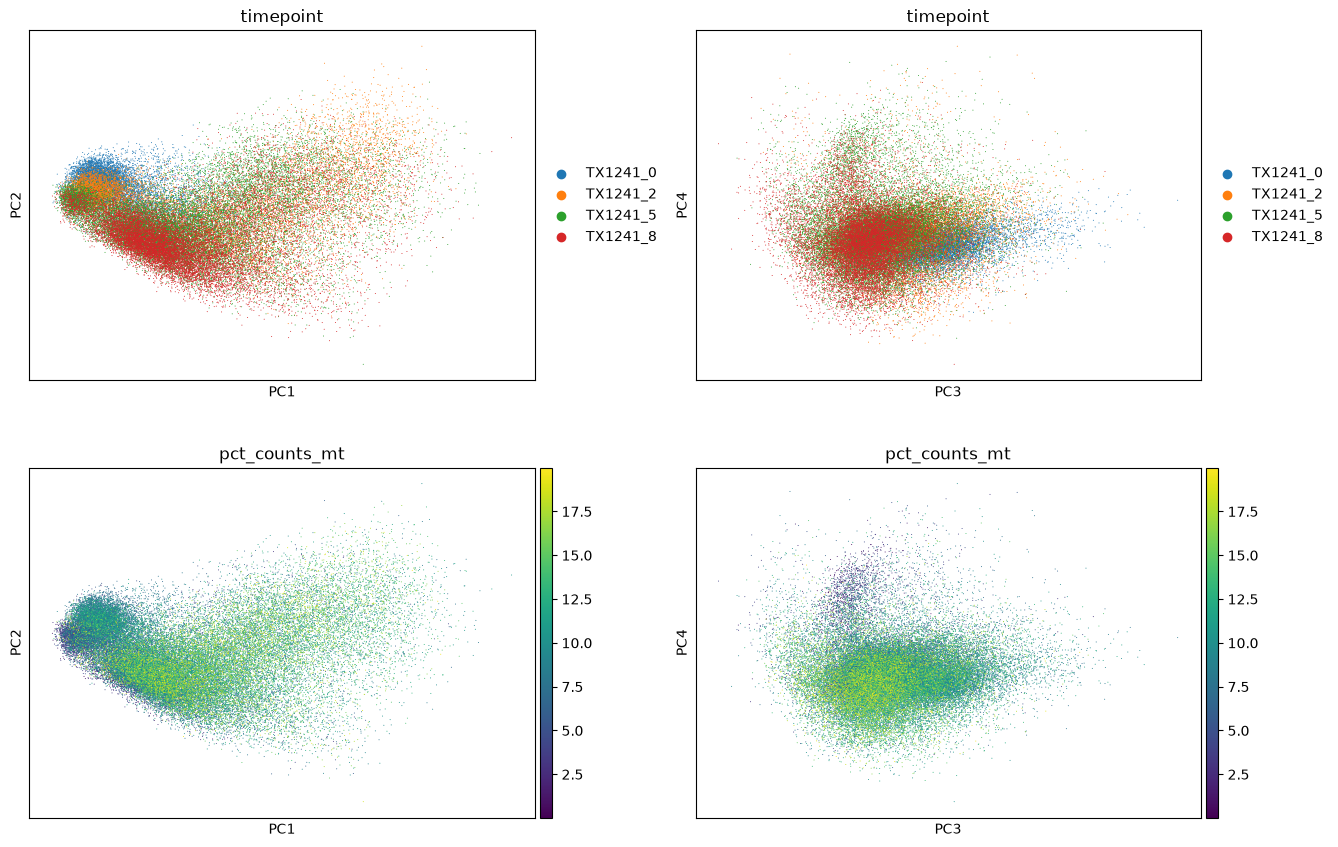

In [6]:
sc.pl.pca(
    adata,
    color=["timepoint", "timepoint", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    wspace=0.2,
    size=2,
)

/Users/davissineath/Documents/03_Code/Research/UM/oncovirus/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


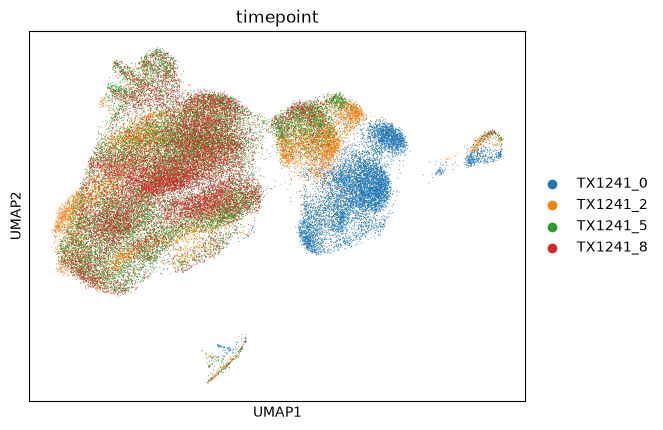

In [7]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color="timepoint",
    size=2,
)

In [8]:
sc.tl.leiden(adata, resolution=0.5, key_added='leiden_res_0.5')
sc.tl.leiden(adata, resolution=1, key_added='leiden_res_1')

/var/folders/88/pb4s0b9n0s9g7yzmv_sft6pr0000gn/T/ipykernel_32006/1412308830.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5, key_added='leiden_res_0.5')
/var/folders/88/pb4s0b9n0s9g7yzmv_sft6pr0000gn/T/ipykernel_32006/1412308830.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False

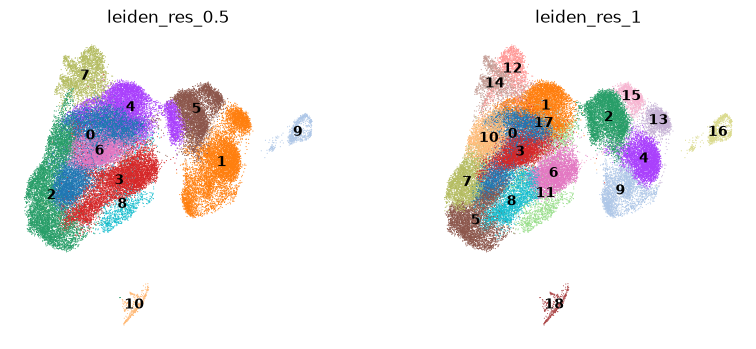

In [9]:
with plt.rc_context({'figure.figsize':(4,4)}):
    sc.pl.umap(adata, color=['leiden_res_0.5','leiden_res_1'], frameon=False, legend_loc='on data')

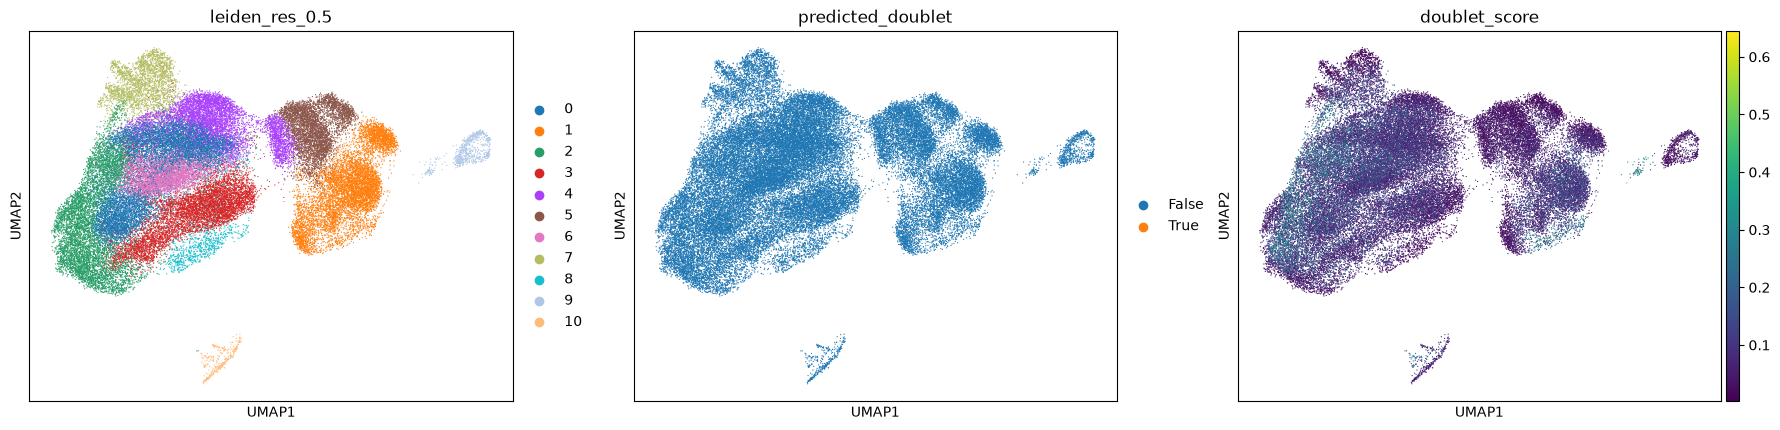

In [10]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.5", "predicted_doublet", "doublet_score"],
    # wspace=0.5,
    size=3,
)

- the total counts per cell (UR)
- the percentage of counts in mitochondrial genes (LL)
- the number of genes expressed in the count matrix (LR)

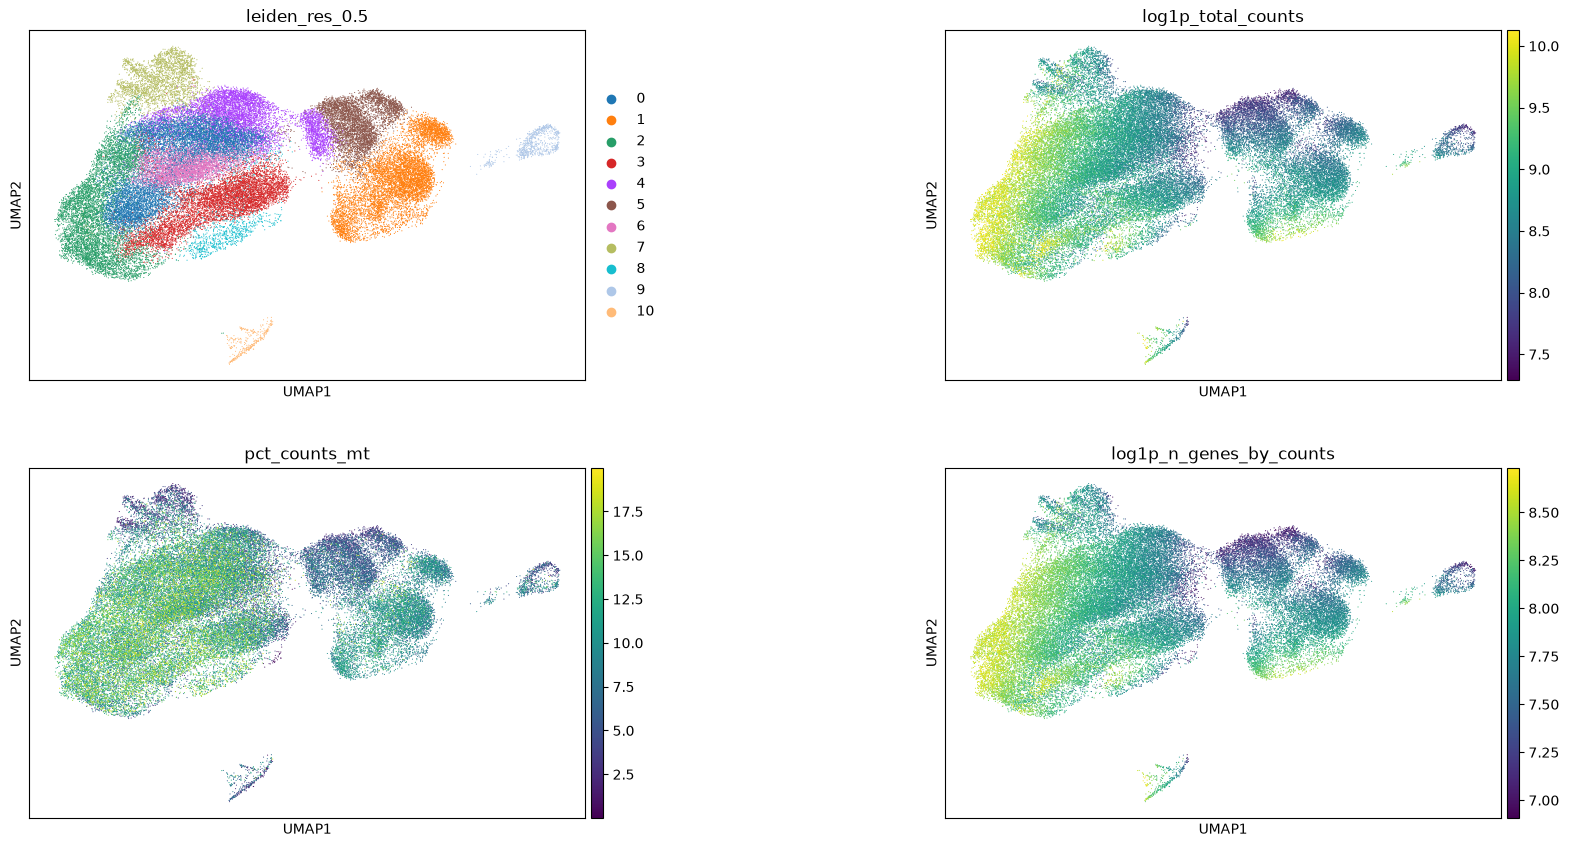

In [11]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.5", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

## Begin Assessing Metabolic Genes Seperately

In [12]:
data_genes = adata.var_names.to_list()
data_genes = [g.split(".")[0] for g in data_genes]
# data_genes

In [13]:
model = cobra.io.read_sbml_model("gems/Recon3D.xml")

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2861474
Academic license 2861474 - for non-commercial use only - registered to ws___@umich.edu


In [14]:
gene_map = pd.read_excel("gene_id_map_recon3d.xlsx", header=1, index_col=0).fillna("")
model_genes = [gene.id for gene in model.genes]

In [15]:
# Can clean into function later
model_gene_HGNC_map = {}
for g in model_genes:
    gid = g.split("_")[0]
    if int(gid) in gene_map.index:
        gsym = gene_map.loc[int(gid), "HGNC symbol"]
        model_gene_HGNC_map[g] = gsym
model_gene_HGNC_map = pd.DataFrame.from_dict(model_gene_HGNC_map, orient="index", columns=["HGNC symbol"])
# model_gene_HGNC_map

In [16]:
subsystem_genes = {}
for rxn in model.reactions:
    sub = rxn.subsystem
    genes = [g.id for g in rxn.genes]

    if len(genes) > 0:
        if sub not in subsystem_genes:
            subsystem_genes[sub] = set()
        for g in genes:
            subsystem_genes[sub].add(g)
        
# subsystem_genes"

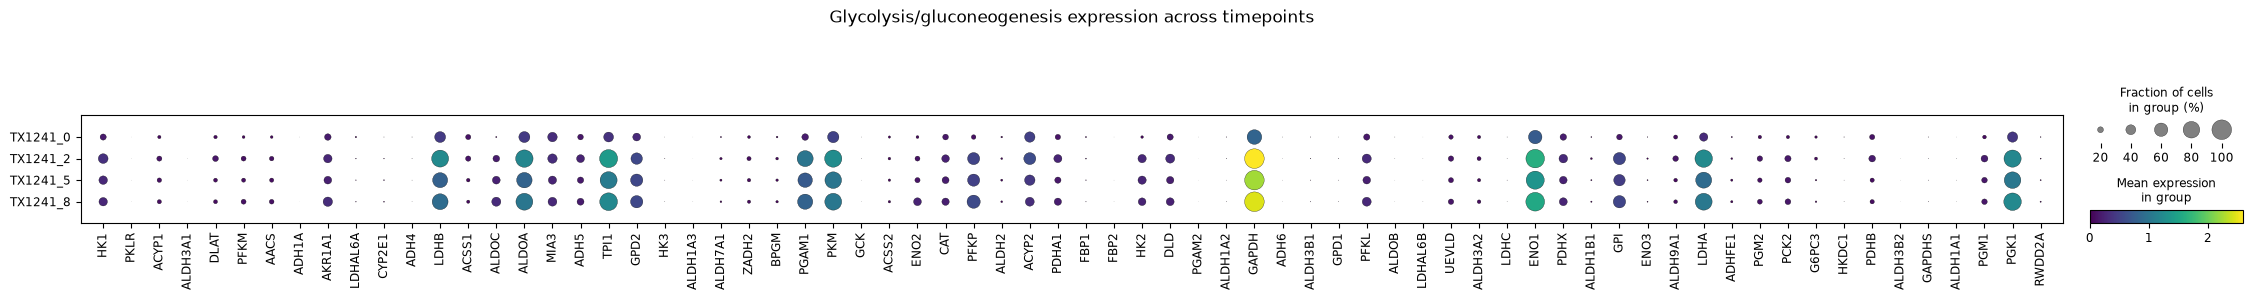

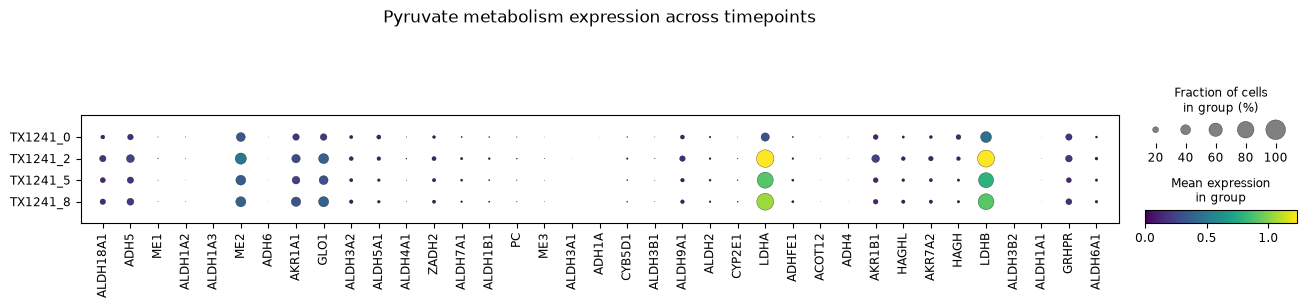

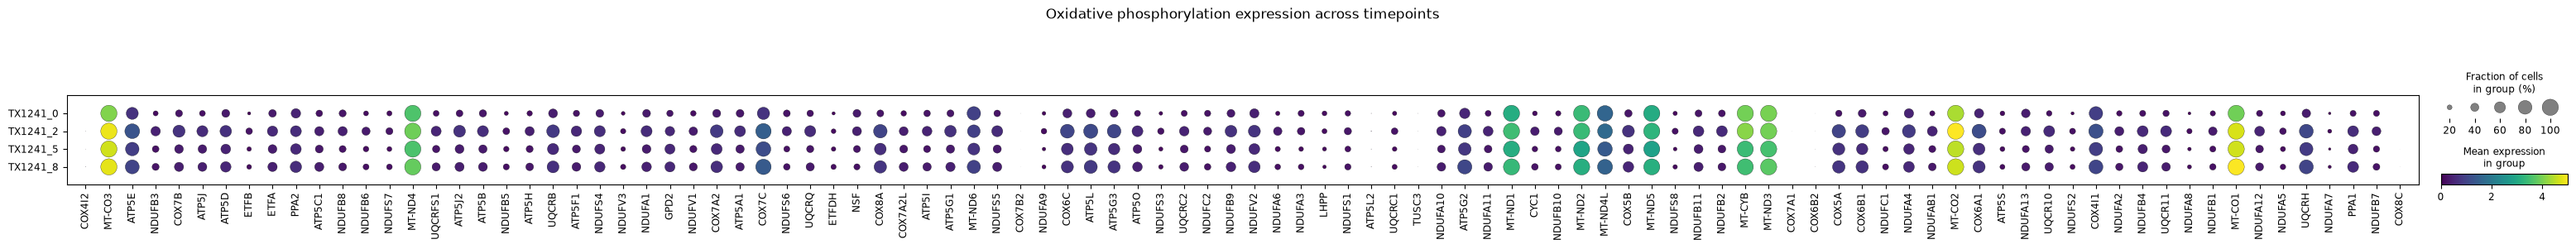

In [17]:
selected_subs = ["Glycolysis/gluconeogenesis",
                 "Pyruvate metabolism",
                 "Oxidative phosphorylation"]

for s in selected_subs:
    gids = subsystem_genes[s]
    sub_genes = (pd.Index(gids).map(model_gene_HGNC_map["HGNC symbol"]))

    sub_genes = (sub_genes[sub_genes.isin(set(data_genes))].unique().tolist())

    sc.pl.dotplot(
        adata,
        var_names=sub_genes,
        groupby="timepoint",
        expression_cutoff=0,
        use_raw=False,       
        standard_scale=None,  
        cmap="viridis",
        dot_min=0,
        dot_max=1,
        title=f'{s} expression across timepoints',
        # save="_timepoints.png",
    )

In [18]:
print(len(model_gene_HGNC_map))
print(len(model_genes))
print(set(model_genes) - set(model_gene_HGNC_map.index.to_list()))

2243
2248
{'200931_AT1', '5446_AT1', '123264_AT1', '0', '8041_AT1'}


Show which model genes not in data

In [19]:
missing_genes = set(model_gene_HGNC_map["HGNC symbol"].to_list()) - set(data_genes)
mapped_genes = set(model_gene_HGNC_map["HGNC symbol"].to_list()).intersection(set(data_genes))
print(len(missing_genes))
print(len(mapped_genes))
print(missing_genes)

131
1745
{'', 'ADH1C', 'UGT1A7', 'ENTPD8', 'PLPPR5', 'AADAT', 'SLC6A14', 'SLC2A10', 'CYP2A13', 'UGT2A1', 'UGT1A9', 'SLC6A10P', 'PLA2G2A', 'GSTM1', 'HAO2', 'MTHFD2P1', 'GGTLC1', 'GK2', 'FTMT', 'PPAP2C', 'SLC34A3', 'CLPS', 'AGXT', 'GGTLC2', 'PRPS1L1', 'TPSAB1', 'SLC17A2', 'CH25H', 'CHST5', 'HYALP1', 'UGT1A4', 'TH', 'ALPP', 'AQP4', 'PPAP2B', 'SLCO1B3', 'AKR1B10', 'SLC17A6', 'PNLIPRP2', 'ADH7', 'TPSD1', 'HS3ST6', 'SOD3', 'UROC1', 'PGK2', 'FABP9', 'UGT1A10', 'HSD3B1', 'SLC6A5', 'NOS2P1', 'UGT1A5', 'GK3P', 'TKTL2', 'GPX5', 'TPI1P2', 'HSD3B2', 'ELOVL3', 'B3GNT1', 'OTC', 'PDHA2', 'CYP2A7', 'CHST1', 'AQP5', 'CYP7A1', 'G6PC', 'FABP1', 'ALPI', 'SLC18A3', 'GPX6', 'UGT1A3', 'G6PC2', 'LALBA', 'CPA1', 'UGT2B10', 'CLC', 'GPX8', 'PSPHP1', 'HSD17B7P2', 'ALPPL2', 'CYP11B2', 'GCNT6', 'PLA2G3', 'CYP21A2', 'LDHD', 'AQP2', 'PLPPR4', 'B3GALT1', 'SLC17A4', 'AKR1C8P', 'CYP2C18', 'CYP11B1', 'PLA2G2E', 'TYRP1', 'SLC52A3', 'LOC286297', 'LOC102724197', 'FABP7', 'CYP2C19', 'LGALS13', 'ATP1B4', 'SLC1A7', 'AGPAT6', 'C

In [20]:
log2_df = adata[:, list(mapped_genes)].to_df(layer="log2").T
# log2_df

In [21]:
metabolic_z_score = pd.DataFrame(stats.zscore(log2_df, axis=1), index=log2_df.index, columns=log2_df.columns)
# metabolic_z_score